In [1]:
!pip install -q transformers accelerate peft bitsandbytes timm pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.2 MB/s eta 0:00:00


In [2]:
import os
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from peft import LoraConfig, get_peft_model
from transformers import BitsAndBytesConfig
from peft import PeftModel
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
import torch.nn.utils.rnn as rnn_utils
import random
from collections import Counter
from torchvision import transforms
import re


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

from google.colab import drive
drive.mount('/content/drive')

CSV_PATH = "/content/drive/MyDrive/VLU-Net-V2/Phase1/DegradationClassifierNew/phase1_captions_dataset.csv"

SAVE_PATH = "/content/drive/MyDrive/VLU-Net-V2/Phase2/Blip2DegradationCaptionNew"

os.makedirs(SAVE_PATH, exist_ok=True)

Mounted at /content/drive


In [4]:
DATASET_ROOT = "/content/VLU-Net/datasets"
CACHE_ROOT = "/content/drive/MyDrive/VLU-Net-V2/datasets_cache"

os.makedirs(DATASET_ROOT, exist_ok=True)

!tar -xf "{CACHE_ROOT}/deblurring_datasets.tar" -C "{DATASET_ROOT}"
!tar -xf "{CACHE_ROOT}/dehazing_datasets.tar" -C "{DATASET_ROOT}"
!tar -xf "{CACHE_ROOT}/denoising_datasets.tar" -C "{DATASET_ROOT}"
!tar -xf "{CACHE_ROOT}/delowlight_datasets.tar" -C "{DATASET_ROOT}"
!tar -xf "{CACHE_ROOT}/deraining_datasets.tar" -C "{DATASET_ROOT}"

print("✓ All datasets extracted")

✓ All datasets extracted


In [5]:
df = pd.read_csv(CSV_PATH)

df["caption"] = df["caption"].apply(lambda x: x.rstrip('.') + '.')

df["image_path"] = df["image_path"].str.replace(
    "/content/drive/MyDrive/VLU-Net-V2/datasets",
    "/content/VLU-Net/datasets",
    regex=False
)
print(df["image_path"].iloc[0])
print(f"Loaded {len(df)} training samples")

/content/VLU-Net/datasets/deblurring_datasets/GoPro/test/blur/0.png
Loaded 2700 training samples


In [6]:
missing = df[~df["image_path"].apply(os.path.exists)]

print("Missing images:", len(missing))

Missing images: 0


In [7]:
model_name = "Salesforce/blip2-opt-2.7b"

processor = Blip2Processor.from_pretrained(model_name)
processor.tokenizer.pad_token = processor.tokenizer.eos_token

bnb_config = BitsAndBytesConfig(load_in_8bit=True)

base_model = Blip2ForConditionalGeneration.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/122k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

trainable params: 2,621,440 || all params: 3,747,383,296 || trainable%: 0.0700


In [8]:
class CaptionDataset(Dataset):
    def __init__(self, dataframe, processor, prompt="Question: Describe the scene. Answer:"):
        self.df = dataframe
        self.processor = processor
        self.prompt = prompt

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        answer = row["caption"]

        full_text = self.prompt + " " + answer

        inputs = self.processor(
            images=image,
            text=full_text,
            return_tensors="pt",
            padding=False,
            truncation=True
        )

        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        prompt_tokens = self.processor.tokenizer(
            self.prompt, return_tensors="pt", add_special_tokens=False
        )["input_ids"][0]
        prompt_len = len(prompt_tokens)

        labels = inputs["input_ids"].clone()
        labels[:prompt_len] = -100

        if labels[-1] != self.processor.tokenizer.eos_token_id:
            labels = torch.cat([labels, torch.tensor([self.processor.tokenizer.eos_token_id])])
            inputs["input_ids"] = torch.cat([inputs["input_ids"], torch.tensor([self.processor.tokenizer.eos_token_id])])
            inputs["attention_mask"] = torch.cat([inputs["attention_mask"], torch.tensor([1])])

        inputs["labels"] = labels
        return inputs

In [9]:
def collate_fn(batch):
    input_ids = [item["input_ids"] for item in batch]
    attention_mask = [item["attention_mask"] for item in batch]
    pixel_values = [item["pixel_values"] for item in batch]
    labels = [item["labels"] for item in batch]

    input_ids = rnn_utils.pad_sequence(input_ids, batch_first=True, padding_value=processor.tokenizer.pad_token_id)
    attention_mask = rnn_utils.pad_sequence(attention_mask, batch_first=True, padding_value=0)
    labels = rnn_utils.pad_sequence(labels, batch_first=True, padding_value=-100)
    pixel_values = torch.stack(pixel_values)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "pixel_values": pixel_values,
        "labels": labels
    }

In [10]:
dataset = CaptionDataset(df, processor)
loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
    collate_fn=collate_fn
)


In [11]:
latest_path = SAVE_PATH + "/latest"
best_path = SAVE_PATH + "/best_model"

best_loss = float("inf")
train_losses = []

start_epoch = 0


In [12]:
if os.path.exists(latest_path):
    print("🔄 Loading latest checkpoint...")

    model = model.from_pretrained(latest_path)
    processor = processor.from_pretrained(latest_path)

    if os.path.exists(latest_path + "/training_state.pt"):
        state = torch.load(latest_path + "/training_state.pt")

        start_epoch = state["epoch"] + 1
        best_loss = state["best_loss"]
        train_losses = state["train_losses"]

    print(f"✔ Resumed from epoch {start_epoch}")

else:
    print("🚀 No checkpoint found, training from scratch")

🚀 No checkpoint found, training from scratch


In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scaler = torch.cuda.amp.GradScaler()

accum_steps = 4
epochs = 10

model.train()

/tmp/ipykernel_4046/1046414193.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Blip2ForConditionalGeneration(
      (vision_model): Blip2VisionModel(
        (embeddings): Blip2VisionEmbeddings(
          (patch_embedding): Conv2d(3, 1408, kernel_size=(14, 14), stride=(14, 14))
        )
        (encoder): Blip2Encoder(
          (layers): ModuleList(
            (0-38): 39 x Blip2EncoderLayer(
              (self_attn): Blip2Attention(
                (qkv): Linear8bitLt(in_features=1408, out_features=4224, bias=True)
                (projection): Linear8bitLt(in_features=1408, out_features=1408, bias=True)
              )
              (layer_norm1): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
              (mlp): Blip2MLP(
                (activation_fn): GELUActivation()
                (fc1): Linear8bitLt(in_features=1408, out_features=6144, bias=True)
                (fc2): Linear8bitLt(in_features=6144, out_features=1408, bias=True)
              )
              (layer_norm2): LayerNo

In [14]:
for epoch in range(start_epoch, epochs):

    model.train()

    total_loss = 0
    optimizer.zero_grad()

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")

    for step, batch in enumerate(pbar):

        batch = {k: v.to(device) for k, v in batch.items()}

        with torch.cuda.amp.autocast():

            outputs = model(**batch)
            loss = outputs.loss / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        loss_val = loss.item() * accum_steps
        total_loss += loss_val

        pbar.set_postfix({
            "loss": f"{loss_val:.4f}",
            "avg": f"{total_loss / (step+1):.4f}",
            "best": f"{best_loss:.4f}"
        })

    avg_loss = total_loss / len(loader)
    train_losses.append(avg_loss)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Avg Loss: {avg_loss:.4f}")


    model.save_pretrained(latest_path)
    processor.save_pretrained(latest_path)

    print("💾 Saved latest checkpoint")

    if avg_loss < best_loss:

        best_loss = avg_loss

        model.save_pretrained(best_path)
        processor.save_pretrained(best_path)

        torch.save({
            "epoch": epoch,
            "best_loss": best_loss
        }, best_path + "/training_state.pt")

        print(f"🔥 New Best Model | Loss: {best_loss:.4f}")


print("🎉 Training complete")

Epoch 1/10:   0%|          | 0/675 [00:00<?, ?it/s]

/tmp/ipykernel_4046/3780461772.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")



Epoch 1/10
Avg Loss: 3.6991
💾 Saved latest checkpoint
🔥 New Best Model | Loss: 3.6991


Epoch 2/10:   0%|          | 0/675 [00:00<?, ?it/s]


Epoch 2/10
Avg Loss: 0.5284
💾 Saved latest checkpoint
🔥 New Best Model | Loss: 0.5284


...


Epoch 8/10
Avg Loss: 0.2121
💾 Saved latest checkpoint
🔥 New Best Model | Loss: 0.2121


Epoch 9/10:   0%|          | 0/675 [00:00<?, ?it/s]


Epoch 9/10
Avg Loss: 0.2036
💾 Saved latest checkpoint
🔥 New Best Model | Loss: 0.2036


Epoch 10/10:   0%|          | 0/675 [00:00<?, ?it/s]


Epoch 10/10
Avg Loss: 0.1954
💾 Saved latest checkpoint
🔥 New Best Model | Loss: 0.1954
🎉 Training complete


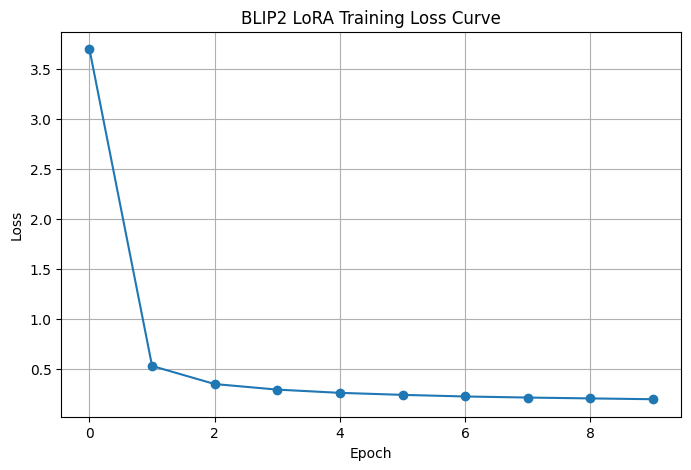

In [15]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o')

plt.title("BLIP2 LoRA Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

In [16]:
def generate_caption(image_path, model, processor, device):
    image = Image.open(image_path).convert("RGB")
    prompt = "Question: Describe the scene. Answer:"
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=50,
            num_beams=3,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            length_penalty=0.8,
            early_stopping=True,
            eos_token_id=processor.tokenizer.eos_token_id,
            pad_token_id=processor.tokenizer.pad_token_id
        )

    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    caption = caption.replace(prompt, "").strip()

    return caption

In [17]:
base_model_inf = Blip2ForConditionalGeneration.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

model_inf = PeftModel.from_pretrained(base_model_inf, best_path)
model_inf.eval()
model_inf.to(device)
torch.set_grad_enabled(False)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [18]:
test_folders = [
    "/content/drive/MyDrive/VLU-Net-V2/datasets/deblurring_datasets/GoPro/test/blur",
    "/content/drive/MyDrive/VLU-Net-V2/datasets/dehazing_datasets/SOTS_outdoors/hazy",
    "/content/drive/MyDrive/VLU-Net-V2/datasets/delowlight_datasets/LoL/eval15/low",
    "/content/drive/MyDrive/VLU-Net-V2/datasets/denoising_datasets/CBSD68/noisy15",
    "/content/drive/MyDrive/VLU-Net-V2/datasets/denoising_datasets/CBSD68/noisy25",
    "/content/drive/MyDrive/VLU-Net-V2/datasets/denoising_datasets/CBSD68/noisy50",
    "/content/drive/MyDrive/VLU-Net-V2/datasets/denoising_datasets/Urban100_HR/noisy15",
    "/content/drive/MyDrive/VLU-Net-V2/datasets/denoising_datasets/Urban100_HR/noisy25",
    "/content/drive/MyDrive/VLU-Net-V2/datasets/denoising_datasets/Urban100_HR/noisy50",
    "/content/drive/MyDrive/VLU-Net-V2/datasets/deraining_datasets/Rain100L/rainy"
]


In [19]:
NUM_SAMPLES = 3

for folder in test_folders:

    print("\n" + "=" * 80)
    print(f"📂 Folder: {os.path.basename(folder)}")
    print("=" * 80)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
    ]

    selected = random.sample(images, min(NUM_SAMPLES, len(images)))

    for img_name in selected:

        img_path = os.path.join(folder, img_name)

        image = Image.open(img_path).convert("RGB")

        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title(img_name)
        plt.show()

        caption = generate_caption(img_path, model_inf, processor, device)

        print("Prediction:", caption)
        print("-" * 80)

Output hidden; open in https://colab.research.google.com to view.

In [20]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [38]:
@torch.inference_mode()
def generate_caption_batch(image_paths, model, processor, device):

    images = [
        Image.open(p).convert("RGB")
        for p in image_paths
    ]

    prompt = "Question: Describe the scene. Answer:"

    inputs = processor(
        images=images,
        text=[prompt] * len(images),
        return_tensors="pt",
        padding=True
    ).to(device)

    generated_ids = model.generate(
            **inputs,
            max_new_tokens=60,
            num_beams=3,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            length_penalty=0.8,
            early_stopping=True,
            eos_token_id=processor.tokenizer.eos_token_id,
            pad_token_id=processor.tokenizer.pad_token_id
        )

    captions = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )

    captions = [
        c.replace(prompt, "").strip()
        for c in captions
    ]

    return captions

In [39]:
def extract_degradation(caption):
    import re
    match = re.search(
        r"(light|moderate|heavy)\s+([a-z]+)\s+conditions",
        caption.lower()
    )

    if match:
        return f"{match.group(1)} {match.group(2)}"

    return "unknown"


def analyze_folder(folder_path, model_inf, processor, device):

    files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
    ]

    batch_size = 16

    counts = Counter()

    pbar = tqdm(
        range(0, len(files), batch_size),
        desc=f"Analyzing {os.path.basename(folder_path)}"
    )

    for i in pbar:

        batch_files = files[i:i+batch_size]
        batch_paths = [os.path.join(folder_path, f) for f in batch_files]

        captions = generate_caption_batch(
            batch_paths,
            model_inf,
            processor,
            device
        )

        for cap in captions:
            label = extract_degradation(cap)
            counts[label] += 1

    total = len(files)

    percentages = {
        k: (v / total) * 100
        for k, v in counts.items()
    }

    print("\n" + "=" * 60)
    print(f"Dataset: {os.path.basename(folder_path)}")
    print("=" * 60)

    for k, v in sorted(percentages.items(), key=lambda x: -x[1]):
        print(f"{k}: {v:.2f}%")

    return counts, percentages

In [40]:
all_results = {}

for folder in tqdm(test_folders,
                   desc="Datasets",
                   unit="dataset"):
    counts, percentages = analyze_folder(
        folder_path=folder,
        model_inf=model_inf,
        processor=processor,
        device=device
    )
    all_results[folder] = percentages


Datasets:   0%|          | 0/10 [00:00<?, ?dataset/s]

Analyzing blur:   0%|          | 0/70 [00:00<?, ?it/s]


Dataset: blur
light blur: 43.29%
moderate blur: 24.66%
heavy blur: 22.68%
light rain: 7.29%
moderate haze: 1.71%
unknown: 0.18%
moderate noise: 0.09%
heavy noise: 0.09%


Analyzing hazy:   0%|          | 0/32 [00:00<?, ?it/s]


Dataset: hazy
moderate haze: 86.80%
heavy haze: 7.60%
moderate noise: 2.20%
heavy noise: 1.20%
moderate lowlight: 0.60%
moderate blur: 0.60%
heavy traffic: 0.20%
heavy rain: 0.20%
heavy lowlight: 0.20%
light blur: 0.20%
light noise: 0.20%


...


Dataset: noisy25
heavy noise: 44.00%
moderate noise: 30.00%
heavy lowlight: 9.00%
light noise: 7.00%
moderate haze: 5.00%
moderate lowlight: 4.00%
heavy blur: 1.00%


Analyzing noisy50:   0%|          | 0/7 [00:00<?, ?it/s]


Dataset: noisy50
heavy noise: 49.00%
moderate noise: 34.00%
heavy lowlight: 6.00%
moderate haze: 5.00%
light noise: 4.00%
heavy blur: 2.00%


Analyzing rainy:   0%|          | 0/7 [00:00<?, ?it/s]


Dataset: rainy
light rain: 96.00%
heavy rain: 3.00%
light noise: 1.00%


In [42]:
data = []

batch_size = 16

for folder in test_folders:

    print(f"\n📂 Folder: {folder}")

    images = sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith(
            ('.png', '.jpg', '.jpeg')
        )
    ])

    for i in range(0, len(images), batch_size):

        batch_files = images[i:i + batch_size]

        batch_paths = [
            os.path.join(folder, f)
            for f in batch_files
        ]

        captions = generate_caption_batch(
            batch_paths,
            model_inf,
            processor,
            device
        )

        for img_path, caption in zip(batch_paths, captions):

            data.append({
                "image_path": img_path,
                "caption": caption
            })

            print("Caption:", caption)


📂 Folder: /content/drive/MyDrive/VLU-Net-V2/datasets/deblurring_datasets/GoPro/test/blur
Caption: This is a street in the city of melbourne, australia in heavy blur conditions.
Caption: This is a street in the city of seoul, south korea in heavy blur conditions.
Caption: This is a street in the city of melbourne, australia in moderate blur conditions.
Caption: This is a traffic jam in seoul, south korea in light blur conditions.
Caption: This is a group of pink hibiscus flowers on the side of the road in light rain conditions.
Caption: This is a group of pink hibiscus flowers on the side of the road in light rain conditions.
Caption: This is a group of pink hibiscus flowers on the side of the road in light rain conditions.
Caption: This is a pink hibiscus bush on the side of the road in light rain conditions.
Caption: This is a group of pink hibiscus flowers on the side of the road in light rain conditions.
Caption: This is a group of pink hibiscus flowers on the side of the road in l

In [43]:
df = pd.DataFrame(data)

save_path = "/content/drive/MyDrive/VLU-Net-V2/Phase2/Blip2DegradationCaptionNew/phase2_captions_dataset.csv"

df.to_csv(save_path, index=False)

print("Dataset saved to:", save_path)
print("Total samples:", len(df))

Dataset saved to: /content/drive/MyDrive/VLU-Net-V2/Phase2/Blip2DegradationCaptionNew/phase2_captions_dataset.csv
Total samples: 2230


In [45]:
!cp -r "/content/drive/MyDrive/VLU-Net-V2/Phase2/Blip2DegradationCaptionNew/best_model" \
"/content/drive/MyDrive/VLU-Net-V2/Phase2/Blip2DegradationCaptionNew/blip2_finetuned_adapter"